# CluMarPareto — Benchmarking
Compares 6 methods across multiple datasets on:
- Runtime (seconds)
- Features selected
- Feature reduction %
- Test accuracy

**Methods:**
1. CluMarPareto (full pipeline)
2. NSGA2 Standalone (on full feature space)
3. DBSCAN + IAMB (stages 1+2 only)
4. IAMB Only (no clustering)
5. Random Forest Importance
6. LASSO

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification

from ucimlrepo import fetch_ucirepo

from Clumarpareto import CluMarPareto
from clustering import DBSCAN_Clustering
from IAMB import IAMB
from NSGA2 import NSGA2_FS

## 2. Dataset Loader

In [2]:
def load_datasets():
    """
    Returns a dict of {name: (X, y)} for each dataset.
    All y are binary (0/1).
    """
    datasets = {}

    # ── 1. Synthetic (controlled ground truth) ──────────────────────────────
    X, y = make_classification(
        n_samples=1000, n_features=50,
        n_informative=10, n_redundant=20,
        n_repeated=5, n_classes=2,
        random_state=42, shuffle=False
    )
    datasets['Synthetic'] = (X, y)
    print("Loaded: Synthetic        ", X.shape)

    # ── 2. Wisconsin Breast Cancer ───────────────────────────────────────────
    try:
        bc = fetch_ucirepo(id=17)
        X_bc = bc.data.features.values.astype(float)
        y_bc = (bc.data.targets.values.ravel() == 'M').astype(int)
        datasets['BreastCancer'] = (X_bc, y_bc)
        print("Loaded: BreastCancer     ", X_bc.shape)
    except Exception as e:
        print(f"BreastCancer failed: {e}")

    # ── 3. SPECTF Heart ──────────────────────────────────────────────────────
    try:
        spectf = fetch_ucirepo(id=96)
        X_sp = spectf.data.features.values.astype(float)
        y_sp = spectf.data.targets.values.ravel().astype(int)
        y_sp = (y_sp > 0).astype(int)
        datasets['SPECTF'] = (X_sp, y_sp)
        print("Loaded: SPECTF           ", X_sp.shape)
    except Exception as e:
        print(f"SPECTF failed: {e}")

    # ── 4. Madelon (high-dim, known redundancy) ───────────────────────────────
    try:
        madelon = fetch_ucirepo(id=171)
        X_mad = madelon.data.features.values.astype(float)
        y_mad = madelon.data.targets.values.ravel().astype(int)
        y_mad = (y_mad == 1).astype(int)
        datasets['Madelon'] = (X_mad, y_mad)
        print("Loaded: Madelon          ", X_mad.shape)
    except Exception as e:
        print(f"Madelon failed: {e}")

    # ── 5. Ionosphere ────────────────────────────────────────────────────────
    # try:
    #     iono = fetch_ucirepo(id=52)
    #     X_io = iono.data.features.values.astype(float)
    #     y_io = (iono.data.targets.values.ravel() == 'g').astype(int)
    #     datasets['Ionosphere'] = (X_io, y_io)
    #     print("Loaded: Ionosphere       ", X_io.shape)
    # except Exception as e:
    #     print(f"Ionosphere failed: {e}")

    return datasets

datasets = load_datasets()

Loaded: Synthetic         (1000, 50)
Loaded: BreastCancer      (569, 30)
Loaded: SPECTF            (267, 44)
Madelon failed: "Madelon" dataset (id=171) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true


## 3. Method Runners
Each runner returns a dict with keys: `runtime`, `n_selected`, `reduction_pct`, `test_acc`

In [3]:
def evaluate_on_test(X_train, X_test, y_train, y_test, selected_indices):
    """Fit a Decision Tree on selected features, return test accuracy."""
    X_tr = X_train[:, selected_indices]
    X_te = X_test[:, selected_indices]
    clf  = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_tr, y_train)
    return clf.score(X_te, y_test)


# ── Method 1: CluMarPareto ───────────────────────────────────────────────────
def run_clumarpareto(X_train, X_test, y_train, y_test, feature_cols):
    train_df = pd.DataFrame(X_train, columns=feature_cols)
    train_df['target'] = y_train

    t0       = time.time()
    pipeline = CluMarPareto(classifier='decisiontree', verbose=False)
    pipeline.fit(train_df)
    runtime  = time.time() - t0

    selected = pipeline.knee_original_indices_
    acc      = evaluate_on_test(X_train, X_test, y_train, y_test, selected)

    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      acc
    }


# ── Method 2: NSGA2 Standalone ───────────────────────────────────────────────
def run_nsga2_standalone(X_train, X_test, y_train, y_test):
    n_features       = X_train.shape[1]
    population_size  = min(200, max(50, 10 * n_features))
    n_generations    = min(200, max(50, population_size // 2))

    t0   = time.time()
    nsga = NSGA2_FS(
        classifier='decisiontree',
        population_size=population_size,
        n_generations=n_generations
    )
    nsga.fit(X_train, y_train)
    runtime = time.time() - t0

    knee     = nsga.find_knee_point(nsga.pareto_front_)
    selected = list(np.where(knee.mask_features)[0])
    acc      = evaluate_on_test(X_train, X_test, y_train, y_test, selected)

    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / n_features) * 100,
        'test_acc':      acc
    }


# ── Method 3: DBSCAN + IAMB ──────────────────────────────────────────────────
def run_dbscan_iamb(X_train, X_test, y_train, y_test, feature_cols):
    t0 = time.time()

    dbscan = DBSCAN_Clustering()
    dbscan.build_distance_matrix(X_train)
    dbscan.cluster_features(feature_names=feature_cols, max_iter=20)

    iamb     = IAMB()
    selected = iamb.run(clusters=dbscan.clusters, X=X_train, y=y_train)
    selected = sorted(set(selected + dbscan.noise))
    runtime  = time.time() - t0

    acc = evaluate_on_test(X_train, X_test, y_train, y_test, selected)

    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      acc
    }


# ── Method 4: IAMB Only ──────────────────────────────────────────────────────
def run_iamb_only(X_train, X_test, y_train, y_test, feature_cols):
    # treat all features as one single cluster
    t0       = time.time()
    iamb     = IAMB()
    all_indices = list(range(X_train.shape[1]))
    selected = iamb.run(
        clusters={0: all_indices},
        X=X_train,
        y=y_train
    )
    runtime  = time.time() - t0

    acc = evaluate_on_test(X_train, X_test, y_train, y_test, selected)

    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      acc
    }


# ── Method 5: Random Forest Importance ───────────────────────────────────────
def run_rf_importance(X_train, X_test, y_train, y_test):
    t0  = time.time()
    rf  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    importances  = rf.feature_importances_
    # select features above mean importance threshold
    threshold    = np.mean(importances)
    selected     = list(np.where(importances >= threshold)[0])
    runtime      = time.time() - t0

    acc = evaluate_on_test(X_train, X_test, y_train, y_test, selected)

    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      acc
    }


# ── Method 6: LASSO ──────────────────────────────────────────────────────────
def run_lasso(X_train, X_test, y_train, y_test):
    t0      = time.time()
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    lasso   = LogisticRegression(
        penalty='l1', solver='liblinear',
        C=0.1, random_state=42, max_iter=1000
    )
    lasso.fit(X_tr_sc, y_train)

    selected = list(np.where(lasso.coef_[0] != 0)[0])
    if len(selected) == 0:
        selected = [int(np.argmax(np.abs(lasso.coef_[0])))]
    runtime  = time.time() - t0

    # evaluate on scaled test set
    X_tr_sel = X_tr_sc[:, selected]
    X_te_sel = X_te_sc[:, selected]
    clf      = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_tr_sel, y_train)
    acc      = clf.score(X_te_sel, y_test)

    return {
        'runtime':       runtime,
        'n_selected':    len(selected),
        'reduction_pct': (1 - len(selected) / X_train.shape[1]) * 100,
        'test_acc':      acc
    }

## 4. Run Benchmark


Dataset: Synthetic  shape=(1000, 50)
  Running CluMarPareto... eps calculated through elbow curve:  0.9208398640548932


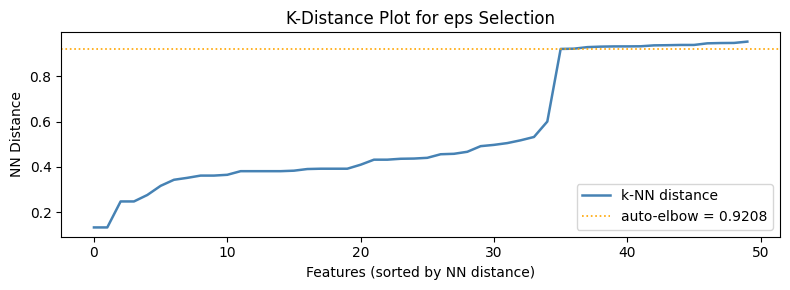

Clusters found : 1
Noise features : 8  (16.0%)
eps decreased to  0.8708398640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8458398640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8333398640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8270898640548932
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8239648640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8224023640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8216211140548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8212304890548932
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8210351765548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8209375203048931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8208886921798931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  

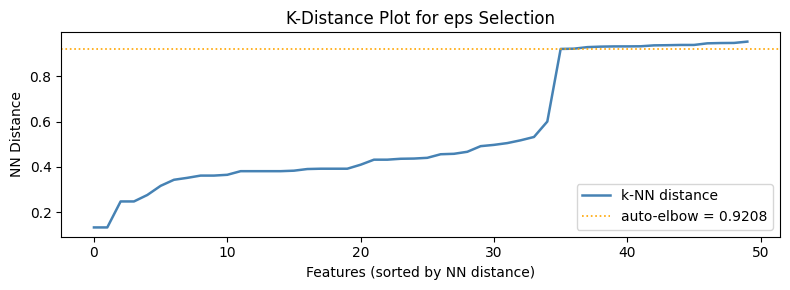

Clusters found : 1
Noise features : 8  (16.0%)
eps decreased to  0.8708398640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8458398640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8333398640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8270898640548932
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8239648640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8224023640548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8216211140548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8212304890548932
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8210351765548931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8209375203048931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  0.8208886921798931
Clusters found : 1
Noise features : 15  (30.0%)
eps decreased to  

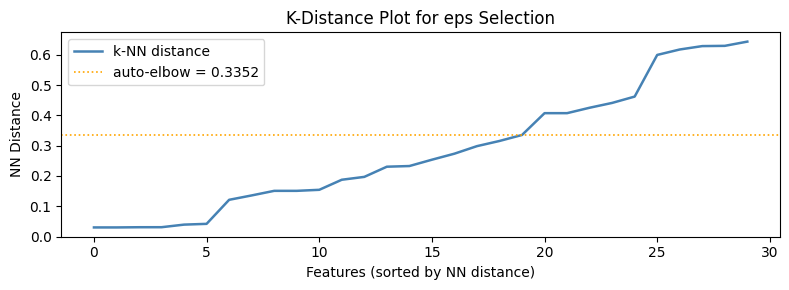

Clusters found : 1
Noise features : 7  (23.3%)
eps decreased to  0.285249967505906
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.26024996750590595
Clusters found : 2
Noise features : 9  (30.0%)

[IAMB] Cluster 0 — features [0, 2, 3, 5, 6, 7, 9, 10, 12, 13, 20, 22, 23, 25, 26, 27, 29]
[0, 2, 3, 5, 6, 7, 9, 10, 12, 13, 20, 22, 23, 25, 26, 27, 29]
Forward phase added feature 10  CMI=0.4576
Forward phase added feature 15  CMI=0.0784
Forward phase added feature 12  CMI=0.0127
Forward phase added feature 9  CMI=0.0085
Forward phase added feature 11  CMI=0.0084
Forward phase added feature 13  CMI=0.0030
Forward phase added feature 4  CMI=0.0029
Forward phase added feature 8  CMI=0.0075
Forward phase added feature 7  CMI=0.0031
Backward phase removed feature 4  CMI=0.0015
Backward phase removed feature 11  CMI=0.0000
Backward phase removed feature 12  CMI=0.0000
Backward phase removed feature 10  CMI=0.0000
  → Selected: [27, 13, 25, 12, 10]

[IAMB] Cluster 1 — features [1

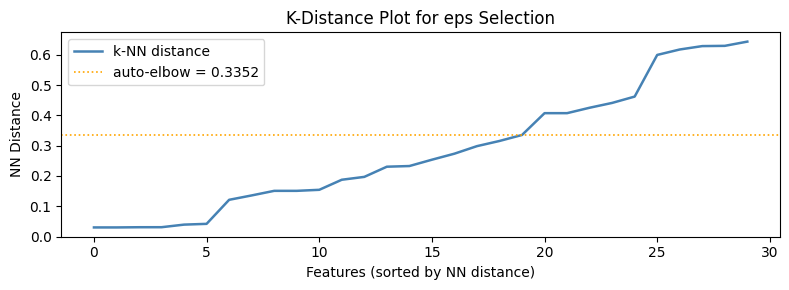

Clusters found : 1
Noise features : 7  (23.3%)
eps decreased to  0.285249967505906
Clusters found : 1
Noise features : 9  (30.0%)
eps decreased to  0.26024996750590595
Clusters found : 2
Noise features : 9  (30.0%)

[IAMB] Cluster 0 — features [0, 2, 3, 5, 6, 7, 9, 10, 12, 13, 20, 22, 23, 25, 26, 27, 29]
[0, 2, 3, 5, 6, 7, 9, 10, 12, 13, 20, 22, 23, 25, 26, 27, 29]
Forward phase added feature 10  CMI=0.4590
Forward phase added feature 15  CMI=0.0787
Forward phase added feature 12  CMI=0.0131
Forward phase added feature 9  CMI=0.0091
Forward phase added feature 11  CMI=0.0072
Forward phase added feature 13  CMI=0.0030
Forward phase added feature 4  CMI=0.0036
Forward phase added feature 8  CMI=0.0086
Forward phase added feature 7  CMI=0.0053
Backward phase removed feature 11  CMI=0.0000
Backward phase removed feature 12  CMI=0.0000
Backward phase removed feature 10  CMI=0.0000
  → Selected: [27, 13, 25, 6, 12, 10]

[IAMB] Cluster 1 — features [15, 16, 17, 19]
[15, 16, 17, 19]
Forward ph

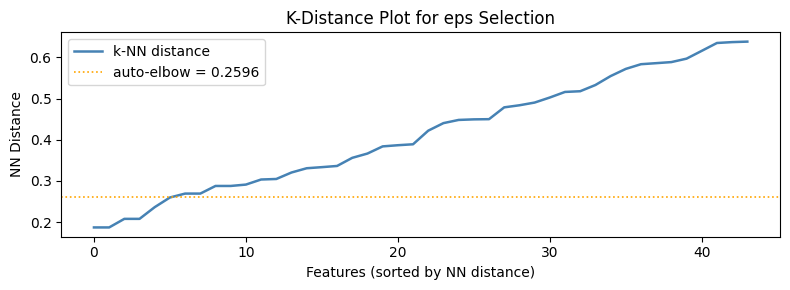

Clusters found : 3
Noise features : 30  (68.2%)
eps increased to:  0.3096364682674862
Clusters found : 2
Noise features : 27  (61.4%)
eps increased to:  0.3346364682674862
Clusters found : 2
Noise features : 26  (59.1%)

[IAMB] Cluster 0 — features [14, 15, 24, 25, 40, 41, 42, 43]
[14, 15, 24, 25, 40, 41, 42, 43]
Forward phase added feature 4  CMI=0.1482
Forward phase added feature 5  CMI=0.0836
Forward phase added feature 0  CMI=0.0582
Forward phase added feature 3  CMI=0.0834
Forward phase added feature 6  CMI=0.0215
Forward phase added feature 1  CMI=0.0100
Forward phase added feature 2  CMI=0.0111
Backward phase removed feature 1  CMI=0.0000
  → Selected: [40, 41, 14, 25, 42, 24]

[IAMB] Cluster 1 — features [6, 7, 16, 17, 28, 29, 34, 35, 38, 39]
[6, 7, 16, 17, 28, 29, 34, 35, 38, 39]
Forward phase added feature 5  CMI=0.0947
Forward phase added feature 8  CMI=0.0560
Forward phase added feature 3  CMI=0.0521
Forward phase added feature 9  CMI=0.0199
Forward phase added feature 0  C

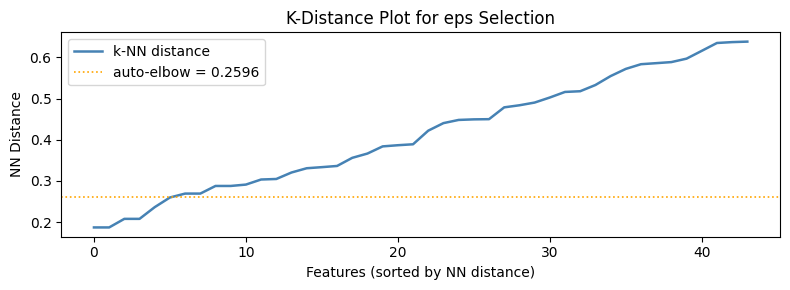

Clusters found : 3
Noise features : 30  (68.2%)
eps increased to:  0.3096364682674862
Clusters found : 2
Noise features : 27  (61.4%)
eps increased to:  0.3346364682674862
Clusters found : 2
Noise features : 26  (59.1%)

[IAMB] Cluster 0 — features [14, 15, 24, 25, 40, 41, 42, 43]
[14, 15, 24, 25, 40, 41, 42, 43]
Forward phase added feature 4  CMI=0.1505
Forward phase added feature 5  CMI=0.0880
Forward phase added feature 3  CMI=0.0529
Forward phase added feature 0  CMI=0.0814
Forward phase added feature 6  CMI=0.0161
Forward phase added feature 2  CMI=0.0100
Forward phase added feature 1  CMI=0.0023
Backward phase removed feature 6  CMI=0.0000
Backward phase removed feature 5  CMI=0.0000
  → Selected: [40, 25, 14, 24, 15]

[IAMB] Cluster 1 — features [6, 7, 16, 17, 28, 29, 34, 35, 38, 39]
[6, 7, 16, 17, 28, 29, 34, 35, 38, 39]
Forward phase added feature 5  CMI=0.1095
Forward phase added feature 8  CMI=0.0492
Forward phase added feature 3  CMI=0.0487
Forward phase added feature 9  CM

,runtime,n_selected,reduction_pct,test_acc,dataset,method,n_total
0,359.745633,5,90.000000,0.860000,Synthetic,CluMarPareto,50
1,349.407696,7,86.000000,0.835000,Synthetic,NSGA2 Standalone,50
2,4.404070,20,60.000000,0.850000,Synthetic,DBSCAN + IAMB,50
3,6.396773,5,90.000000,0.820000,Synthetic,IAMB Only,50
4,0.107310,18,64.000000,0.835000,Synthetic,RF Importance,50
5,0.013073,13,74.000000,0.825000,Synthetic,LASSO,50
6,278.231733,5,83.333333,0.973684,BreastCancer,CluMarPareto,30
7,350.032311,7,76.666667,0.929825,BreastCancer,NSGA2 Standalone,30
8,1.636070,19,36.666667,0.912281,BreastCancer,DBSCAN + IAMB,30
9,1.820894,3,90.000000,0.929825,BreastCancer,IAMB Only,30


In [4]:
METHODS = [
    'CluMarPareto',
    'NSGA2 Standalone',
    'DBSCAN + IAMB',
    'IAMB Only',
    'RF Importance',
    'LASSO'
]

results = []  # list of dicts, one per (dataset, method)

for dataset_name, (X, y) in datasets.items():
    print("\n" + "=" * 60)
    print(f"Dataset: {dataset_name}  shape={X.shape}")
    print("=" * 60)

    feature_cols = [f"f{i}" for i in range(X.shape[1])]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    runners = {
        'CluMarPareto':     lambda: run_clumarpareto(X_train, X_test, y_train, y_test, feature_cols),
        'NSGA2 Standalone': lambda: run_nsga2_standalone(X_train, X_test, y_train, y_test),
        'DBSCAN + IAMB':    lambda: run_dbscan_iamb(X_train, X_test, y_train, y_test, feature_cols),
        'IAMB Only':        lambda: run_iamb_only(X_train, X_test, y_train, y_test, feature_cols),
        'RF Importance':    lambda: run_rf_importance(X_train, X_test, y_train, y_test),
        'LASSO':            lambda: run_lasso(X_train, X_test, y_train, y_test),
    }

    for method_name, runner in runners.items():
        print(f"  Running {method_name}...", end=' ', flush=True)
        try:
            res = runner()
            res['dataset'] = dataset_name
            res['method']  = method_name
            res['n_total'] = X.shape[1]
            results.append(res)
            print(f"done — acc={res['test_acc']:.4f}  "
                  f"features={res['n_selected']}/{X.shape[1]}  "
                  f"time={res['runtime']:.1f}s")
        except Exception as e:
            print(f"FAILED: {e}")
            results.append({
                'dataset': dataset_name, 'method': method_name,
                'runtime': None, 'n_selected': None,
                'reduction_pct': None, 'test_acc': None,
                'n_total': X.shape[1]
            })

results_df = pd.DataFrame(results)
print("\n\nAll runs complete.")
results_df

## 5. Results Table
Pivot table — rows = datasets, columns = methods

In [6]:
def pivot_metric(metric, fmt='{:.4f}'):
    tbl = results_df.pivot(index='dataset', columns='method', values=metric)
    tbl = tbl[METHODS]  # consistent column order
    return tbl.style.format(fmt).highlight_max(axis=1, color='lightgreen') \
                                .highlight_min(axis=1, color='lightyellow')

print("Test Accuracy")
pivot_metric('test_acc', '{:.4f}')

Test Accuracy


method,CluMarPareto,NSGA2 Standalone,DBSCAN + IAMB,IAMB Only,RF Importance,LASSO
dataset,,,,,,
BreastCancer,0.9737,0.9298,0.9123,0.9298,0.9386,0.9386
SPECTF,0.6852,0.7037,0.7407,0.8148,0.7222,0.7593
Synthetic,0.8600,0.8350,0.8500,0.8200,0.8350,0.8250


In [7]:
print("Runtime (seconds)")
pivot_metric('runtime', '{:.2f}')

Runtime (seconds)


method,CluMarPareto,NSGA2 Standalone,DBSCAN + IAMB,IAMB Only,RF Importance,LASSO
dataset,,,,,,
BreastCancer,278.23,350.03,1.64,1.82,0.08,0.00
SPECTF,353.72,517.32,0.77,2.28,0.08,0.00
Synthetic,359.75,349.41,4.40,6.40,0.11,0.01


In [8]:
print("Features Selected")
pivot_metric('n_selected', '{:.0f}')

Features Selected


method,CluMarPareto,NSGA2 Standalone,DBSCAN + IAMB,IAMB Only,RF Importance,LASSO
dataset,,,,,,
BreastCancer,5,7,19,3,9,7
SPECTF,5,6,33,1,17,9
Synthetic,5,7,20,5,18,13


In [9]:
print("Feature Reduction %")
pivot_metric('reduction_pct', '{:.1f}%')

Feature Reduction %


method,CluMarPareto,NSGA2 Standalone,DBSCAN + IAMB,IAMB Only,RF Importance,LASSO
dataset,,,,,,
BreastCancer,83.3%,76.7%,36.7%,90.0%,70.0%,76.7%
SPECTF,88.6%,86.4%,25.0%,97.7%,61.4%,79.5%
Synthetic,90.0%,86.0%,60.0%,90.0%,64.0%,74.0%


## 6. Visualizations

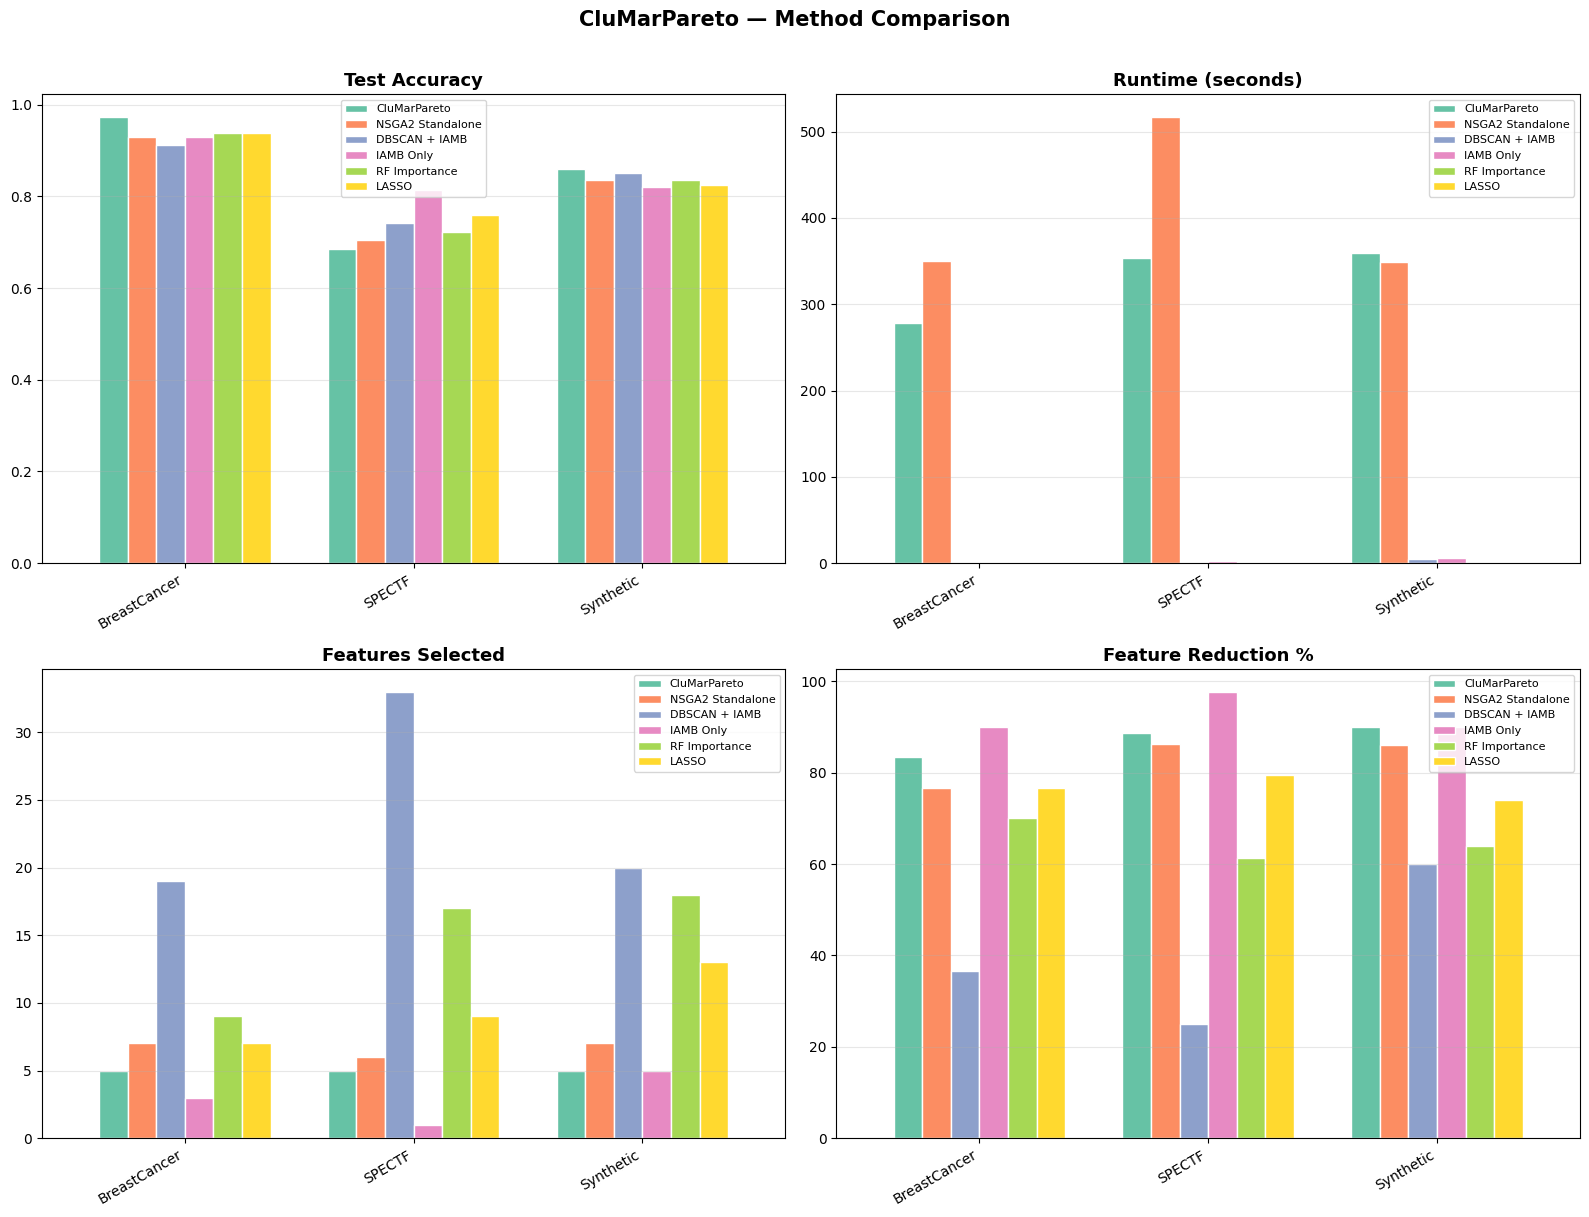

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics   = ['test_acc', 'runtime', 'n_selected', 'reduction_pct']
titles    = ['Test Accuracy', 'Runtime (seconds)', 'Features Selected', 'Feature Reduction %']
colors    = sns.color_palette('Set2', len(METHODS))

for ax, metric, title in zip(axes.flat, metrics, titles):
    pivot = results_df.pivot(index='dataset', columns='method', values=metric)
    pivot = pivot[METHODS]
    pivot.plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.75)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8, loc='best')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('CluMarPareto — Method Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('benchmark_comparison1.png', dpi=150, bbox_inches='tight')
plt.show()

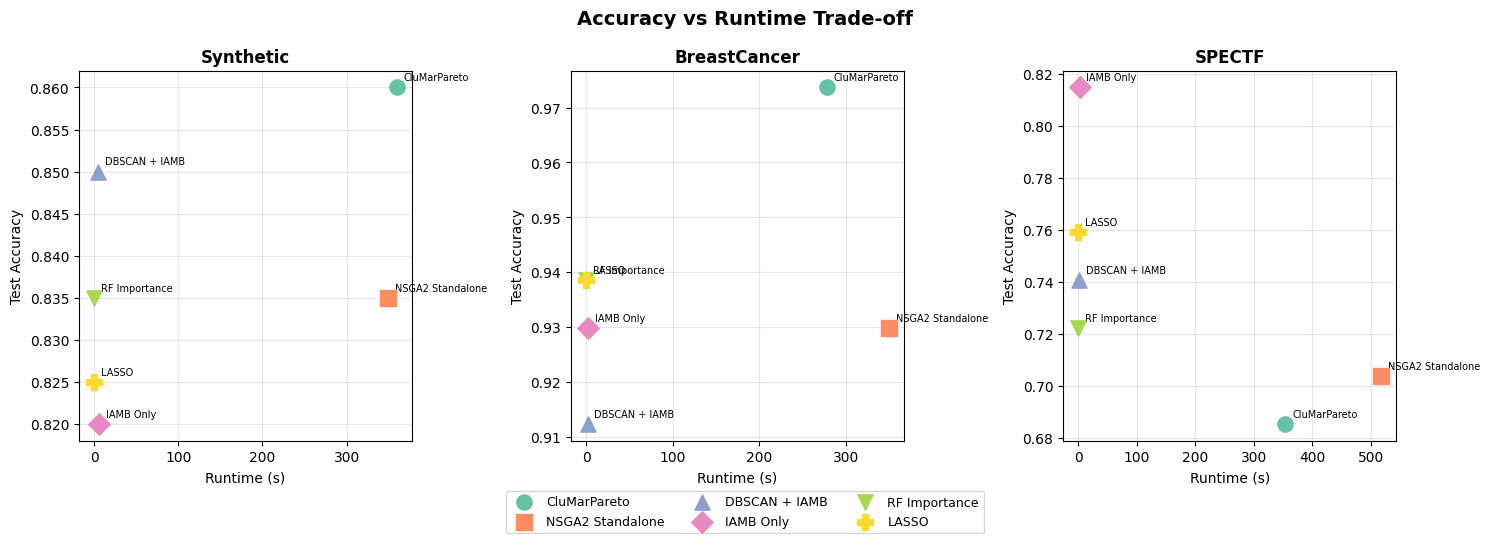

In [11]:
# Accuracy vs Runtime scatter — key plot for the paper
fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

markers = ['o', 's', '^', 'D', 'v', 'P']

for ax, (dataset_name, _) in zip(axes, datasets.items()):
    sub = results_df[results_df['dataset'] == dataset_name]
    for i, method in enumerate(METHODS):
        row = sub[sub['method'] == method]
        if row.empty or row['runtime'].isna().any():
            continue
        ax.scatter(
            row['runtime'], row['test_acc'],
            label=method, s=120,
            marker=markers[i], color=colors[i], zorder=5
        )
        ax.annotate(
            method, 
            (row['runtime'].values[0], row['test_acc'].values[0]),
            textcoords='offset points', xytext=(5, 5), fontsize=7
        )
    ax.set_title(dataset_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Runtime (s)')
    ax.set_ylabel('Test Accuracy')
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)
plt.suptitle('Accuracy vs Runtime Trade-off', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_vs_runtime1.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Statistics
Average rank across datasets for each method — lower is better.

In [12]:
# Rank each method per dataset (1 = best)
# For accuracy: higher is better → ascending=False
# For runtime:  lower  is better → ascending=True
# For n_selected: lower is better → ascending=True

rank_acc  = results_df.pivot(index='dataset', columns='method', values='test_acc')[METHODS]
rank_rt   = results_df.pivot(index='dataset', columns='method', values='runtime')[METHODS]
rank_nsel = results_df.pivot(index='dataset', columns='method', values='n_selected')[METHODS]

avg_rank_acc  = rank_acc.rank(axis=1,  ascending=False).mean()
avg_rank_rt   = rank_rt.rank(axis=1,   ascending=True).mean()
avg_rank_nsel = rank_nsel.rank(axis=1, ascending=True).mean()

summary = pd.DataFrame({
    'Avg Rank (Accuracy↑)':  avg_rank_acc,
    'Avg Rank (Runtime↓)':   avg_rank_rt,
    'Avg Rank (Features↓)':  avg_rank_nsel,
})
summary['Overall Avg Rank'] = summary.mean(axis=1)
summary = summary.sort_values('Overall Avg Rank')

print("Average Rank across all datasets (lower = better)")
summary.style.format('{:.2f}').highlight_min(color='lightgreen')

Average Rank across all datasets (lower = better)


,Avg Rank (Accuracy↑),Avg Rank (Runtime↓),Avg Rank (Features↓),Overall Avg Rank
method,,,,
LASSO,2.88,1.00,3.88,2.58
IAMB Only,3.50,3.75,1.62,2.96
RF Importance,3.00,2.00,4.62,3.21
CluMarPareto,3.50,5.33,1.67,3.50
NSGA2 Standalone,3.25,5.25,2.38,3.62
DBSCAN + IAMB,4.00,3.00,6.00,4.33


In [13]:
# Save full results to CSV for paper
results_df.to_csv('benchmark_results.csv', index=False)
summary.to_csv('benchmark_summary.csv')
print("Results saved to benchmark_results.csv and benchmark_summary.csv")

Results saved to benchmark_results.csv and benchmark_summary.csv
